# Tarea 5 — Radar Clasico Comparativo

> Crear un radar clasico para comparar a dos jugadores de la misma posicion del `radars.csv`. Deben ser jugadores de la misma posicion, pero cambiar el tipo de dato mostrado respecto al temario (que usaba delanteros). Usar `drop` para quitar los datos del CSV que no interesan.

**Jugadores seleccionados:** Bruno Fernandes (Manchester United) vs Alexis Mac Allister (Brighton) — Mediocampistas (MF)

**Cambio respecto al temario:** En el tema 10 se compararon delanteros (Tammy Abraham vs Harry Kane) con metricas de tiro. Aqui comparamos mediocampistas y eliminamos con `drop` las columnas de tiro especificas de delanteros (FK, PK, PKatt, etc.) para quedarnos con metricas mas relevantes para mediocampistas.

In [1]:
# Instalacion de soccerplots (libreria para radar comparativo)
%pip install soccerplots

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importacion de librerias
# pandas: carga de datos tabulares y filtrado
# matplotlib.pyplot: renderizado de figuras (gestionado internamente por soccerplots)
# soccerplots.radar_chart.Radar: renderiza un radar comparativo de dos jugadores
#   con dos poligonos superpuestos sobre los mismos ejes.
#   A diferencia de PyPizza (basado en percentiles), este radar usa valores absolutos
#   escalados a rangos por eje, ideal para comparaciones directas.
import pandas as pd
import matplotlib.pyplot as plt
from soccerplots.radar_chart import Radar

# Cargamos el CSV de estadisticas de FBref para la Premier League 2020/21
df = pd.read_csv('../data/radars10.csv')

# Limpiamos los nombres de jugadores (formato FBref: "Nombre\slug-url")
df['Player'] = df['Player'].str.split('\\', expand=True)[0]
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches


In [3]:
# Filtramos a los dos mediocampistas que vamos a comparar.
# Bruno Fernandes tiene posicion 'MF' y Mac Allister tiene posicion 'MFFW'
# (mediocampista con caracteristicas ofensivas). Ambos son mediocampistas
# de perfil creativo/ofensivo, lo que hace la comparacion mas interesante.
# reset_index() restablece los indices para que .iloc[0] y .iloc[1] sean accesibles.
df = df[(df['Player'] == 'Bruno Fernandes') | (df['Player'] == 'Alexis Mac Allister')].reset_index()
df

,index,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,141,142,Bruno Fernandes,pt POR,MF,Manchester Utd,26-175,1994,24.4,15,...,22.9,11,7,8,11.7,5.6,0.07,3.3,2.4,Matches
1,269,270,Alexis Mac Allister,ar ARG,MFFW,Brighton,22-068,1998,8.3,1,...,20.4,1,0,0,0.9,0.9,0.05,0.1,0.1,Matches


In [4]:
# Usamos 'drop' para eliminar columnas que no son relevantes para mediocampistas.
# En el tema 10 se usaron metricas de delanteros (Gls, SoT%, G/Sh, G/SoT, etc.)
# Para mediocampistas, eliminamos:
#   - Columnas administrativas: index, Rk, Nation, Pos, Squad, Age, Born
#   - Metricas de tiro puro de delanteros: SoT%, G/Sh, G/SoT (conversion de tiro)
#   - Metricas de penales/faltas: FK, PK, PKatt (mas relevantes para delanteros/especialistas)
#   - Columna de metadatos: Matches
#   - 90s: diferente minutaje jugado — distorsionaria la comparacion
df = df.drop(['index', 'Rk', 'Nation', 'Pos', 'Squad', 'Age', 'Born',
              '90s', 'SoT%', 'G/Sh', 'G/SoT', 'FK', 'PK', 'PKatt', 'Matches'], axis=1)
df

,Player,Gls,Sh,SoT,Sh/90,SoT/90,Dist,xG,npxG,npxG/Sh,G-xG,np:G-xG
0,Bruno Fernandes,15,77,28,3.16,1.15,22.9,11.7,5.6,0.07,3.3,2.4
1,Alexis Mac Allister,1,20,3,2.41,0.36,20.4,0.9,0.9,0.05,0.1,0.1


In [5]:
# Extraemos los nombres de las metricas como etiquetas de los ejes del radar.
# params[1:] omite la columna 'Player' que es un identificador, no una metrica.
params = list(df.columns)
params = params[1:]
print(f"Metricas para el radar ({len(params)}):")
print(params)

# Construimos los rangos de cada eje (min, max) con una expansion del 25%
# para que ningun valor quede exactamente en el borde del radar.
# Cada eje se escala independientemente, lo que permite comparar metricas
# con magnitudes muy distintas (ej: Goles=6 vs Tiros=85).
ranges = []
a_values = []
b_values = []

for x in params:
    a = min(df[params][x])
    a = a - (a * .25)  # limite inferior: 25% por debajo del minimo

    b = max(df[params][x])
    b = b + (b * .25)  # limite superior: 25% por encima del maximo

    ranges.append((a, b))

# Extraemos los valores crudos por jugador como listas de Python.
for x in range(len(df['Player'])):
    if df['Player'][x] == 'Alexis Mac Allister':
        a_values = df.iloc[x].values.tolist()
    if df['Player'][x] == 'Bruno Fernandes':
        b_values = df.iloc[x].values.tolist()

# Eliminamos el nombre del jugador (primer elemento) de cada lista
a_values = a_values[1:]
b_values = b_values[1:]

values = [a_values, b_values]
print(f"\nAlexis Mac Allister: {a_values}")
print(f"Bruno Fernandes: {b_values}")

Metricas para el radar (11):
['Gls', 'Sh', 'SoT', 'Sh/90', 'SoT/90', 'Dist', 'xG', 'npxG', 'npxG/Sh', 'G-xG', 'np:G-xG']

Alexis Mac Allister: [np.int64(1), np.int64(20), np.int64(3), np.float64(2.41), np.float64(0.36), np.float64(20.4), np.float64(0.9), np.float64(0.9), np.float64(0.05), np.float64(0.1), np.float64(0.1)]
Bruno Fernandes: [np.int64(15), np.int64(77), np.int64(28), np.float64(3.16), np.float64(1.15), np.float64(22.9), np.float64(11.7), np.float64(5.6), np.float64(0.07), np.float64(3.3), np.float64(2.4)]


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

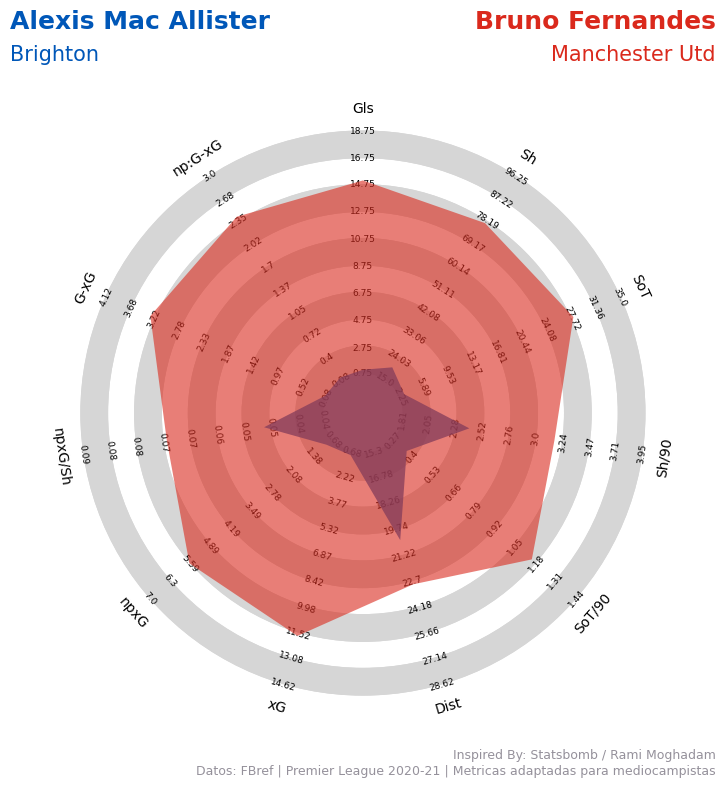

In [6]:
# Configuracion del titulo del radar comparativo.
# Soporta dos entradas de jugador con nombre, color, subtitulo de club y tamano de fuente.
title = dict(
    title_name='Alexis Mac Allister',
    title_color='#0057B8',       # Azul del Brighton
    subtitle_name='Brighton',
    subtitle_color='#0057B8',
    title_name_2='Bruno Fernandes',
    title_color_2='#DA291C',     # Rojo del Manchester United
    subtitle_name_2='Manchester Utd',
    subtitle_color_2='#DA291C',
    title_fontsize=18,
    subtitle_fontsize=15
)

endnote = 'Datos: FBref | Premier League 2020-21 | Metricas adaptadas para mediocampistas'

# Radar() instancia el renderizador de soccerplots.
# radar.plot_radar() renderiza la comparacion dual:
#   ranges: tuplas (min, max) por eje para controlar la escala
#   params: nombres de metricas como etiquetas de ejes
#   values: [[macallister_stats], [bruno_stats]] — vectores de estadisticas
#   radar_color: colores de relleno de cada poligono
#   alphas: transparencia del relleno. 0.75 para el primer jugador, 0.6 para el segundo
#   compare=True: activa el modo de renderizado de dos jugadores
radar = Radar()

fig, ax = radar.plot_radar(
    ranges=ranges,
    params=params,
    values=values,
    radar_color=['#0057B8', '#DA291C'],
    alphas=[.75, .6],
    title=title,
    endnote=endnote,
    compare=True,
)

plt.show()

## Analisis del radar comparativo — Bruno Fernandes vs Alexis Mac Allister

Esta comparacion entre dos mediocampistas creativos de la Premier League 2020/21 revela diferencias importantes pese a compartir un perfil similar:

1. **Bruno Fernandes — Volumen ofensivo superior:** Bruno domina claramente en metricas de produccion ofensiva como goles (Gls), tiros (Sh), tiros a puerta (SoT), xG y npxG. Esto se explica por su rol central en el Manchester United como el principal referente creativo y goleador del mediocampo.

2. **Alexis Mac Allister — Jugador emergente:** Mac Allister, en su primera temporada completa en la Premier League con el Brighton, muestra numeros mas modestos pero con eficiencia notable. Con solo 8.3 jornadas completas jugadas, sus numeros por partido reflejan un jugador con gran potencial que empezaba a mostrar la calidad que lo llevaria a ser campeon del mundo con Argentina en 2022.

3. **Diferencia de minutaje:** Es importante considerar que Bruno jugo 24.4 jornadas completas frente a las 8.3 de Mac Allister. Los valores absolutos favorecen naturalmente a quien juega mas, por lo que las metricas de ratio (Sh/90, SoT/90) ofrecen una comparacion mas justa.

4. **Uso de `drop`:** Eliminamos las columnas de tiro especificas de delanteros (SoT%, G/Sh, G/SoT) y las de set pieces (FK, PK, PKatt) que no aportan informacion relevante para el perfil de mediocampistas creativos. Esto permite que el radar se enfoque en metricas que realmente describen su contribucion ofensiva.

**Conclusion:** Bruno Fernandes era claramente el mediocampista ofensivo mas influyente de la liga en esa temporada, mientras que Mac Allister mostraba destellos del talento que lo convertiria en uno de los mediocampistas mas cotizados de Europa anos despues. El radar refleja la diferencia entre un jugador consolidado en un gran club y un talento emergente en un equipo en crecimiento.